# 02 — Clustering & Phase Mapping
## Machine Learning in SPM Tutorial
*RMS AFM & SPM Meeting 2026*

## Goals

By the end of this notebook you will be able to:

- Understand clustering intuitively and why it is useful for SPM data
- Apply KMeans and Gaussian Mixture Model (GMM) clustering to SPM-like hyperspectral data
- Compare resulting cluster maps against a known ground truth using quantitative metrics
- Understand how PCA preprocessing improves clustering performance and speed

## Why Clustering for SPM?

SPM data often originates from samples containing multiple distinct phases — for example ferroelectric domain structures with opposing polarisation states, polymer blends with chemically distinct components, or polycrystalline materials where each grain has a different crystallographic orientation. Each phase produces a characteristic spectral or force-curve signature that varies from pixel to pixel across the image.

Clustering algorithms automatically group pixels with similar spectral or physical signatures into discrete classes, without requiring any pre-existing labels or manual segmentation. The algorithm discovers the natural groupings present in the data, making it a powerful exploratory tool when the number or nature of phases is not known in advance.

Phase mapping by clustering is therefore particularly useful when investigating unknown samples, when manual threshold-based segmentation would be subjective or time-consuming, or when the phases differ across many spectral channels simultaneously rather than in a single contrast channel.

In [1]:
# --- Colab bootstrap: clone the repo & install deps when running on Google Colab ---
# (Does nothing when you run locally from the cloned repo.)
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('RMS-AFM-SPM-Meeting-2026'):
        !git clone -q https://github.com/Liambcollins/RMS-AFM-SPM-Meeting-2026.git
    %cd RMS-AFM-SPM-Meeting-2026/notebooks
    !pip -q install scikit-image >/dev/null 2>&1
    print('Colab setup complete.')

In [2]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt

from synthetic.generators import make_hyperspectral_spm, make_domain_image
from ml.pca_tools import pca_decompose, component_maps
from ml.clustering import cluster_cube, relabel_by_size
from viz.plotting import set_style, plot_cluster_map, compare_images

set_style()

## Generate Synthetic Phase-Separated Data

In [3]:
cube, true_spectra, true_maps, freq = make_hyperspectral_spm(
    n_x=40, n_y=40, n_freq=64, n_components=3, noise_level=0.25, random_state=7)

# Ground truth phase map: dominant component per pixel
gt_map = true_maps.argmax(axis=0)
print(f"Cube: {cube.shape}, unique phases: {np.unique(gt_map)}")

Cube: (40, 40, 64), unique phases: [0 1 2]


## Visualise the Raw Data and Ground Truth

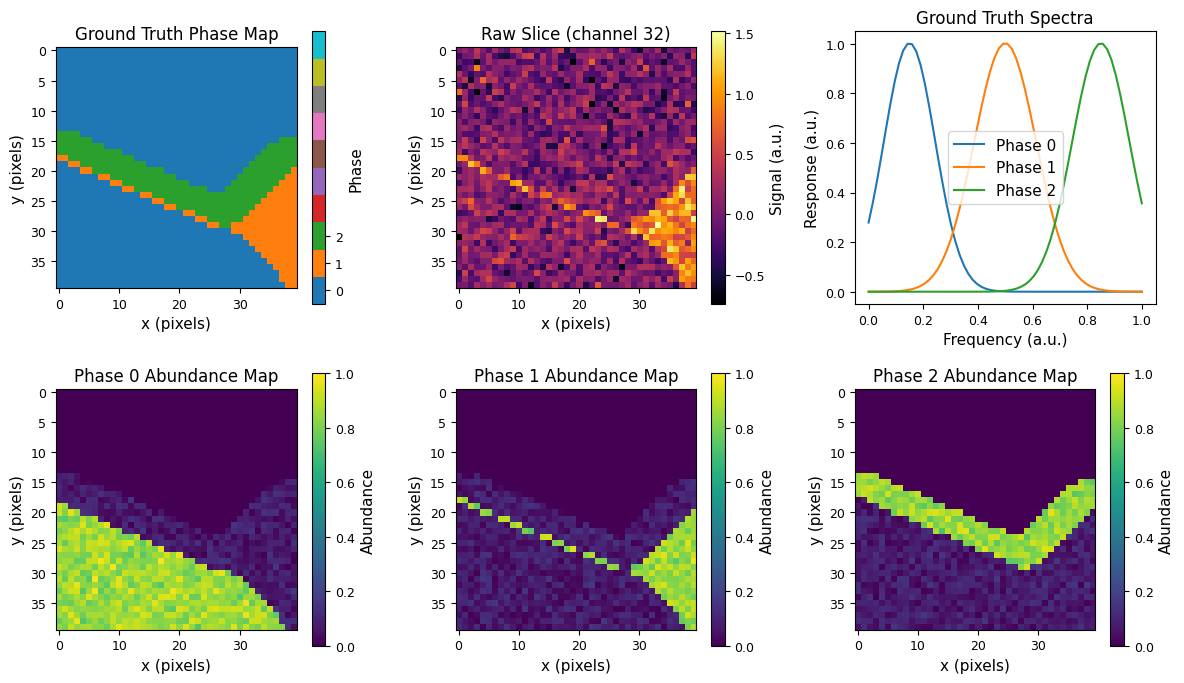

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

# Row 1, col 0: Ground truth phase map
im0 = axes[0, 0].imshow(gt_map, cmap='tab10', vmin=-0.5, vmax=9.5)
axes[0, 0].set_title('Ground Truth Phase Map')
axes[0, 0].set_xlabel('x (pixels)')
axes[0, 0].set_ylabel('y (pixels)')
fig.colorbar(im0, ax=axes[0, 0], ticks=[0, 1, 2], label='Phase')

# Row 1, col 1: One noisy frequency slice (middle channel)
mid_ch = cube.shape[2] // 2
im1 = axes[0, 1].imshow(cube[:, :, mid_ch], cmap='inferno')
axes[0, 1].set_title(f'Raw Slice (channel {mid_ch})')
axes[0, 1].set_xlabel('x (pixels)')
axes[0, 1].set_ylabel('y (pixels)')
fig.colorbar(im1, ax=axes[0, 1], label='Signal (a.u.)')

# Row 1, col 2: Ground-truth spectra for all 3 phases
for i, (spec, colour) in enumerate(zip(true_spectra, ['tab:blue', 'tab:orange', 'tab:green'])):
    axes[0, 2].plot(freq, spec, color=colour, label=f'Phase {i}')
axes[0, 2].set_xlabel('Frequency (a.u.)')
axes[0, 2].set_ylabel('Response (a.u.)')
axes[0, 2].set_title('Ground Truth Spectra')
axes[0, 2].legend()

# Row 2: spatial abundance maps for each phase
for i in range(3):
    im = axes[1, i].imshow(true_maps[i], cmap='viridis', vmin=0, vmax=1)
    axes[1, i].set_title(f'Phase {i} Abundance Map')
    axes[1, i].set_xlabel('x (pixels)')
    axes[1, i].set_ylabel('y (pixels)')
    fig.colorbar(im, ax=axes[1, i], label='Abundance')

fig.tight_layout()
plt.show()

## Preprocessing: PCA Before Clustering

Raw hyperspectral SPM data typically has many correlated channels (64 frequency bins in this example). Before clustering, it is good practice to project the data into its principal components (PCA scores). This step has two main benefits:

- **Noise reduction**: most of the measurement noise lives in high-order PCs that explain very little variance. By retaining only the top 10 components we discard the noise while preserving the physically meaningful variance.
- **Speed**: clustering algorithms run much faster in a 10-dimensional space than in a 64-dimensional one, and are less susceptible to the curse of dimensionality.

A rule of thumb is to retain enough components to explain at least 90–95% of the total variance.

In [5]:
scores, components, evr, pca_model = pca_decompose(cube, n_components=10, return_model=True)
print(f"Top 10 PCs explain {evr.sum()*100:.1f}% of variance")

# Reshape scores to spatial
n_x, n_y = cube.shape[:2]
score_cube = scores.reshape(n_x, n_y, -1)

Top 10 PCs explain 56.0% of variance


## KMeans Clustering

In [6]:
from ml.clustering import kmeans_cluster
from sklearn.preprocessing import StandardScaler

flat_scores = scores  # already (n_pixels, n_pcs)
scaler = StandardScaler()
flat_scaled = scaler.fit_transform(flat_scores)

labels_km, km_model = kmeans_cluster(flat_scaled, n_clusters=3, random_state=42)
km_map = relabel_by_size(labels_km.reshape(n_x, n_y))
print(f"KMeans cluster sizes: {np.bincount(km_map.ravel())}")

KMeans cluster sizes: [747 492 361]


Adjusted Rand Index (KMeans): 0.418  [1.0 = perfect, 0 = random]


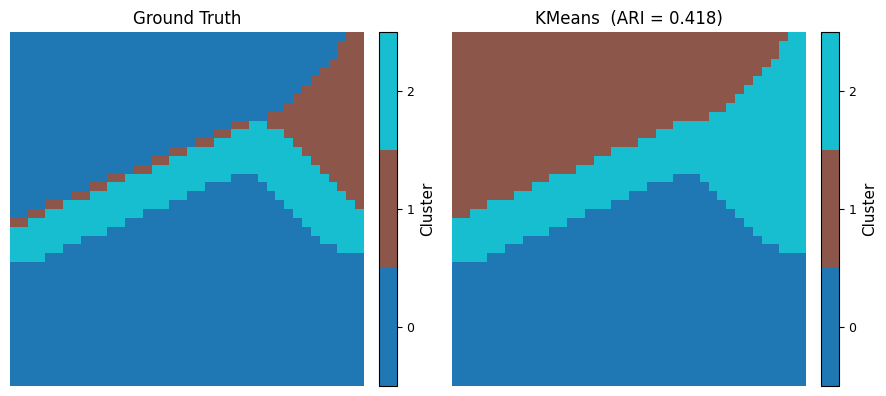

In [7]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(gt_map.ravel(), km_map.ravel())
print(f"Adjusted Rand Index (KMeans): {ari:.3f}  [1.0 = perfect, 0 = random]")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

plot_cluster_map(gt_map, ax=axes[0], title='Ground Truth')
plot_cluster_map(km_map, ax=axes[1], title=f'KMeans  (ARI = {ari:.3f})')

fig.tight_layout()
plt.show()

## Gaussian Mixture Model Clustering

KMeans assigns each pixel to exactly one cluster using hard, spherical boundaries in feature space. A **Gaussian Mixture Model (GMM)** is a more flexible approach: it models the data as a weighted sum of multivariate Gaussian distributions and computes, for each pixel, the *probability* of belonging to each cluster. This is often called **soft clustering**.

Soft clustering is particularly valuable in SPM when phases do not have sharp boundaries — for example at grain boundaries in a polycrystalline film or at the interface between two polymer domains where spectral signatures blend continuously. The membership probability maps can reveal such transition zones that hard clustering would obscure.

In [8]:
from ml.clustering import gmm_cluster

labels_gmm, probs_gmm, gmm_model = gmm_cluster(flat_scaled, n_components=3, random_state=42)
gmm_map = relabel_by_size(labels_gmm.reshape(n_x, n_y))

ari_gmm = adjusted_rand_score(gt_map.ravel(), gmm_map.ravel())
print(f"Adjusted Rand Index (GMM): {ari_gmm:.3f}")

Adjusted Rand Index (GMM): 0.281


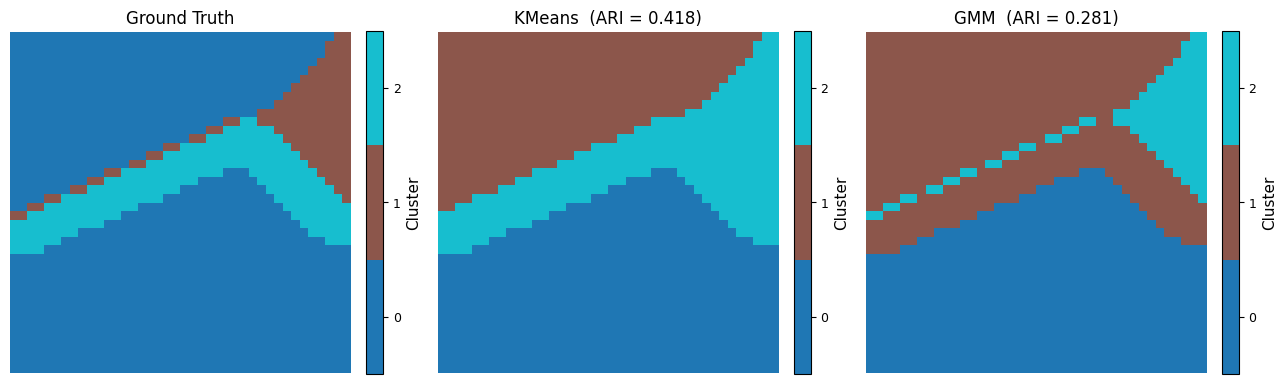

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

plot_cluster_map(gt_map, ax=axes[0], title='Ground Truth')
plot_cluster_map(km_map, ax=axes[1], title=f'KMeans  (ARI = {ari:.3f})')
plot_cluster_map(gmm_map, ax=axes[2], title=f'GMM  (ARI = {ari_gmm:.3f})')

fig.tight_layout()
plt.show()

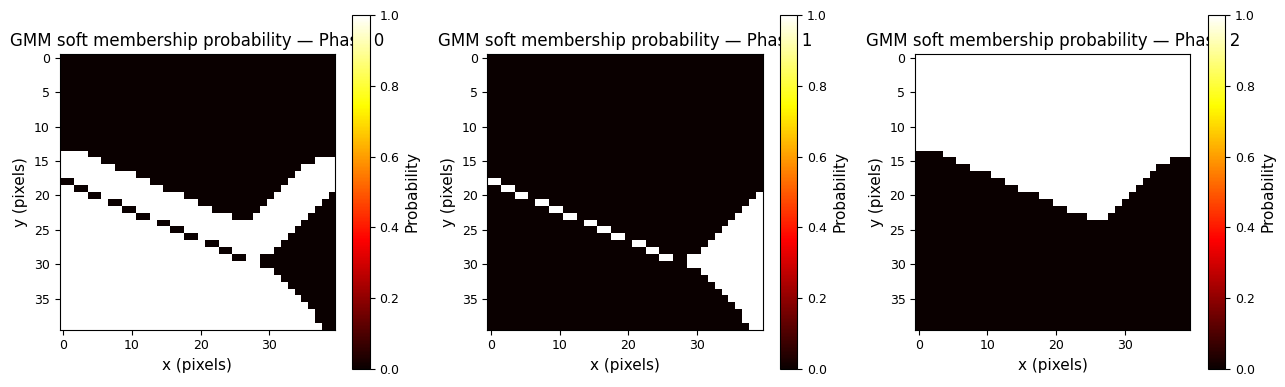

In [10]:
prob_cube = probs_gmm.reshape(n_x, n_y, 3)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i in range(3):
    im = axes[i].imshow(prob_cube[:, :, i], cmap='hot', vmin=0, vmax=1)
    axes[i].set_title(f'GMM soft membership probability — Phase {i}')
    axes[i].set_xlabel('x (pixels)')
    axes[i].set_ylabel('y (pixels)')
    fig.colorbar(im, ax=axes[i], label='Probability')

fig.tight_layout()
plt.show()

## Choosing the Number of Clusters

In practice the number of phases is often unknown. Two complementary diagnostics help guide the choice of *k*:

- **Elbow method**: plot the total within-cluster inertia (sum of squared distances to cluster centres) as a function of *k*. The inertia always decreases with more clusters, but the rate of improvement typically slows sharply at the true *k*, producing a visible "elbow".
- **Silhouette score**: for each point this metric measures how similar it is to its own cluster compared to the nearest other cluster. Scores range from −1 to +1; a higher average score indicates better-defined, well-separated clusters. The score usually peaks near the true *k*.

Using both methods together gives a more robust estimate than either alone.

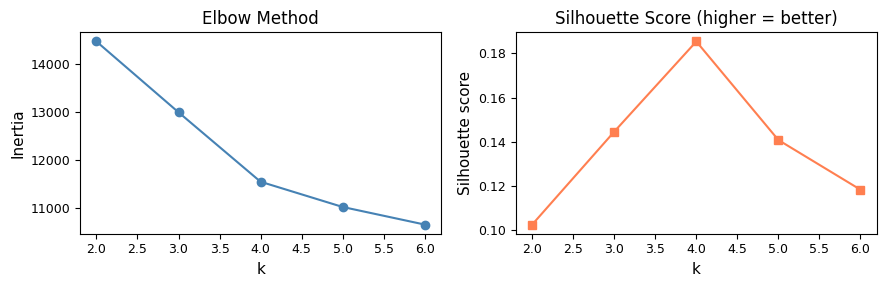

In [11]:
from sklearn.cluster import KMeans as KM
from sklearn.metrics import silhouette_score

ks = range(2, 7)
inertias, silhouettes = [], []

for k in ks:
    km = KM(n_clusters=k, random_state=42, n_init=5).fit(flat_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(flat_scaled, km.labels_, sample_size=500))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(list(ks), inertias, 'o-', color='steelblue')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(list(ks), silhouettes, 's-', color='coral')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette Score (higher = better)')

fig.tight_layout()
plt.show()

## Bonus — Force-volume clustering reveals a hidden mechanical phase

Clustering isn't just for spectra. In **force-volume AFM** every pixel stores a full force–distance curve. Here
the *topography* shows only **two** height regions — but clustering the **force curves** uncovers **three**
mechanical phases: two areas that look identical in height have different stiffness.

> Tip: cluster the force curves on their PCA scores **without** per-feature standardisation — the curve
> *magnitude* is exactly what encodes stiffness, so we don't want to scale it away.

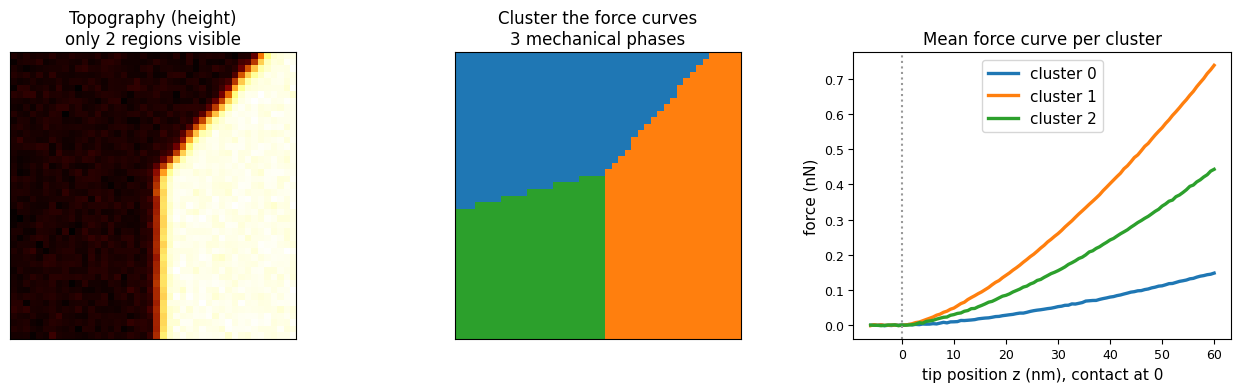

A phase invisible in topography is obvious once you cluster the mechanics.


In [12]:
from synthetic.generators import make_force_volume
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

height, force, z_nm, true_phase = make_force_volume(
    size=44, n_z=100, z_min_nm=-6.0, z_max_nm=60.0,
    moduli_kpa=(40, 120, 200), e_jitter=0.04, noise_nn=0.02, random_state=3)

flat = force.reshape(-1, force.shape[2])          # one force curve per pixel
scores = PCA(n_components=5, random_state=0).fit_transform(flat)
labels = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(scores).reshape(height.shape)

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].imshow(height, cmap='afmhot', origin='lower')
ax[0].set_title('Topography (height)\nonly 2 regions visible')
ax[1].imshow(labels, cmap='tab10', origin='lower', vmin=0, vmax=9)
ax[1].set_title('Cluster the force curves\n3 mechanical phases')
for i in range(3):
    m = labels.ravel() == i
    ax[2].plot(z_nm, flat[m].mean(0), lw=2.4, label=f'cluster {i}')
ax[2].axvline(0, color='0.6', ls=':'); ax[2].set_title('Mean force curve per cluster')
ax[2].set_xlabel('tip position z (nm), contact at 0'); ax[2].set_ylabel('force (nN)'); ax[2].legend()
for a in ax[:2]: a.set_xticks([]); a.set_yticks([])
fig.tight_layout(); plt.show()
print('A phase invisible in topography is obvious once you cluster the mechanics.')

## Takeaways

- **Clustering finds phases without labels**: both KMeans and GMM can recover phase structure in hyperspectral SPM data purely from the data distribution, with no manual annotation required.
- **PCA preprocessing removes noise and accelerates computation**: projecting 64 spectral channels down to 10 PCA scores discards measurement noise in high-order components while retaining the variance that separates phases, leading to cleaner and faster clustering.
- **GMM gives soft, probabilistic assignments**: unlike KMeans' hard boundaries, GMM computes per-pixel membership probabilities that expose transition zones and mixed-phase regions near domain walls or interfaces — information that hard clustering discards.
- **Always compare cluster maps to any known reference**: use quantitative metrics such as the Adjusted Rand Index and visual overlay against ground-truth maps, chemical maps, or other contrast channels to validate that the discovered clusters correspond to physically meaningful phases.